In [1]:
from IPython.display import HTML
display(HTML("""
<style>
@import url('https://fonts.googleapis.com/css2?family=Montserrat:ital,wght@0,300;0,400;0,700;1,400&display=swap');
</style>
"""))

<h1 style="color:teal; font-size:45px; font-family:'Montserrat', sans-serif; font-weight:bold; margin-bottom: 5px;">
HDDL — Mini-projet 1 —  Chats ou Chiens ?
</h1>

<p style="color:#444; font-size:12px; font-family:'Montserrat', sans-serif; border-bottom: 3px solid #2980b9; padding-bottom: 10px; font-weight:bold; margin-top: 0px;">
Dataset - The Oxford-IIIT Pet Dataset 
</p>
<p style="font-size:16px; font-family:'Montserrat'; color:#34495e; margin-top: 0px; text-align: right;">
EHRHART Elsa, HOSSEINI Arman, SLISSE Paul, STAUB Guillaume
</p>

<div style="margin-top: 30px;">
</div>
<div style="background-color: #ecf5fb; border-left: 15px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
<h2 style="color: teal; ">Index</h2>
<ul style="list-style-type: none; padding-left: 0;">
    <li style="margin-bottom: 8px;">
            <a href="#00" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">0.</span>
                <span style="color: #2c3e50; font-weight: 600;">Imports</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#10" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">1.</span>
                <span style="color: #2c3e50; font-weight: 600;">Analyse exploratoire</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#20" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">2.</span>
                <span style="color: #2c3e50; font-weight: 600;">Classification binaire</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#30" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">3.</span>
                <span style="color: #2c3e50; font-weight: 600;">Classification fine</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#40" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">4.</span>
                <span style="color: #2c3e50; font-weight: 600;">Segmentation des animaux</span>
            </a>
        </li>
        <li style="margin-bottom: 8px;">
            <a href="#50" style="text-decoration: none; display: flex; align-items: baseline;">
                <span style="min-width: 40px; font-weight: bold; color: #2980b9;">5.</span>
                <span style="color: #2c3e50; font-weight: 600;">Analyse comparative</span>
            </a>
        </li>
    <!--
    <ul style="list-style-type: circle; padding-left: 60px;">
        <li><a href="#21" style="color:#2c3e50; text-decoration: none;">2.1 </a></li>
    </ul>
    -->
</ul>
</div>
<div id="00"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    0. Imports
</h2>

In [ ]:
%load_ext autoreload
%autoreload 2

import numpy as np

# Data visualization
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.patches import Rectangle
import matplotlib.cm as cm


import math

# Utils
import os
import shutil
import time
import re
import cv2
import gc
from PIL import Image

# Maths - Stats
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

import pandas as pd
import random

#torch
import torch
import torch.nn as nn
import torch.optim as optim

import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import datasets, transforms, models
from torchsummary import summary

from tqdm import tqdm  # Barre de progression


if torch.cuda.is_available():
    device = torch.device("cuda")
else :
    try :
        import torch_directml
        device = torch_directml.device()
    except :
        device = torch.device("cpu")
print(device)

RANDOM_SEED = 42

# Configure la graine pour la reproductibilité
def set_seed(seed):
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)

set_seed(RANDOM_SEED)

cuda


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;">Importation des données</strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
O. M. Parkhi, A. Vedaldi, A. Zisserman, C. V. Jawahar
   Cats and Dogs  
   IEEE Conference on Computer Vision and Pattern Recognition, 2012

Dataset contenant 37 categories d'animaux avec environ 200 images de chaque classe.

trimaps/ 	Trimap annotations for every image in the dataset  
		Pixel Annotations: 1: Foreground 2:Background 3: Not classified
xmls/		Head bounding box annotations in PASCAL VOC Format

list.txt	Combined list of all images in the dataset
- Each entry in the file is of following nature:
- Image CLASS-ID SPECIES BREED ID
- ID: 1:37 Class ids
- SPECIES: 1:Cat 2:Dog
- BREED ID: 1-25:Cat 1:12:Dog
All images with 1st letter as captial are cat images while images with small first letter are dog images.
trainval.txt	Files describing splits used in the paper.However,
test.txt	you are encouraged to try random splits.

(cf readme)

In [3]:
# --- 1. Définition des chemins ---
path = "../oxford-iiit-pet/"
annotations_path = os.path.join(path, "annotations")
images_path = os.path.join(path, "images") 

print(f"Chemin des annotations : {annotations_path}")
print(f"Chemin des images : {images_path}")

# --- 2. Lecture du fichier principal (list.txt) pour les labels ---

list_txt_path = os.path.join(annotations_path, "list.txt")
all_labels_data = []

try:
    with open(list_txt_path, 'r') as f:
        for line in f:
            line = line.strip()
            # Ignorer les lignes vides ou les commentaires (commençant par #)
            if not line or line.startswith('#'):
                continue
            
            # Diviser la ligne en gérant les espaces multiples
            parts = re.split(r'\s+', line)
            
            if len(parts) == 4:
                # Les fichiers d'annotation n'ont pas d'extension, mais les images si.
                image_name = parts[0] + ".jpg" 
                class_id = int(parts[1])
                species = int(parts[2])  # 1:Cat, 2:Dog
                breed_id = int(parts[3])
                
                # Mapper SPECIES (1:Cat, 2:Dog) à category (0:Cat, 1:Dog)
                category = 0 if species == 1 else 1 # 0 pour Chat (Species 1), 1 pour Chien (Species 2)
                
                all_labels_data.append([image_name, class_id, species, breed_id, category])

    # Créer un DataFrame principal avec toutes les informations
    labels_df = pd.DataFrame(
        all_labels_data, 
        columns=['filename', 'CLASS-ID', 'SPECIES', 'BREED ID', 'category']
    )
    
    print(f"\nLabels chargés avec succès depuis list.txt. Total : {len(labels_df)} images.")
    # print(labels_df.head()) 

    def get_mask_path(filename):
    # Le masque est dans 'annotations/trimaps/' et a l'extension '.png'
        mask_name = filename.replace(".jpg", ".png")
        return os.path.join(annotations_path, "trimaps", mask_name)


    # Créer les colonnes pour les chemins complets
    labels_df['mask_path'] = labels_df['filename'].apply(get_mask_path)
    labels_df['img_path'] = labels_df['filename'].apply(lambda f: os.path.join(images_path, f))



    print(f"Images lues depuis list.txt : {len(labels_df)}")

except FileNotFoundError:
    print(f"ERREUR: Le fichier {list_txt_path} n'a pas été trouvé.")
    # Quitter ou gérer l'erreur
    #exit()

Chemin des annotations : ../oxford-iiit-pet/annotations
Chemin des images : ../oxford-iiit-pet/images

Labels chargés avec succès depuis list.txt. Total : 7349 images.
Images lues depuis list.txt : 7349


<div id="10"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
1. Analyse exploratoire

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On sépare les données en ensembles de train, test et validation.

In [4]:
# 1. Première division : (Train + Validation) et Test
# Nous stratifions sur 'category' pour garder les proportions de chats/chiens
RANDOM_SEED=42

train_val_df, test_df = train_test_split(
    labels_df,
    test_size=0.3,
    random_state=RANDOM_SEED,
    stratify=labels_df['category']
)



# 2. Deuxième division : Train et Validation (à partir du train_val_df)
# Nous re-stratifions pour garantir les proportions dans les deux ensembles
total_train_df, total_validation_df = train_test_split(
    train_val_df,
    test_size=0.2, 
    random_state=RANDOM_SEED,
    stratify=train_val_df['category']
)

# Réinitialiser les index pour un affichage propre et éviter les erreurs de .copy()
total_train_df = total_train_df.reset_index(drop=True).copy()
total_validation_df = total_validation_df.reset_index(drop=True).copy()
test_df = test_df.reset_index(drop=True).copy()
train_val_df = train_val_df.reset_index(drop=True).copy()

# --- 6. Conversion de la colonne 'category' en string ---

total_train_df['category'] = total_train_df['category'].astype(str)
total_validation_df['category'] = total_validation_df['category'].astype(str)
test_df['category'] = test_df['category'].astype(str)
train_val_df['category'] = train_val_df['category'].astype(str)

total_train_df.drop('SPECIES',axis=1,inplace=True)
total_validation_df.drop('SPECIES',axis=1,inplace=True)
test_df.drop('SPECIES',axis=1,inplace=True)
train_val_df.drop('SPECIES',axis=1,inplace=True)

# --- 7. Affichage des résultats ---

print("\n--- Aperçu du DataFrame d'entraînement sans validation (train_val_df) ---")
print(train_val_df.head())
print(f"\nDistribution des classes (Train) :\n{train_val_df['category'].value_counts()}")

print("\n--- Aperçu du DataFrame d'entraînement (total_train_df) ---")
print(total_train_df.head())
print(f"\nDistribution des classes (Train) :\n{total_train_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de validation (total_validation_df) ---")
print(total_validation_df.head())
print(f"\nDistribution des classes (Validation) :\n{total_validation_df['category'].value_counts()}")


print("\n--- Aperçu du DataFrame de test (test_df) ---")
print(test_df.head())
print(f"\nDistribution des classes (Test) :\n{test_df['category'].value_counts()}")


--- Aperçu du DataFrame d'entraînement sans validation (train_val_df) ---
                  filename  CLASS-ID  BREED ID category  \
0     basset_hound_112.jpg         4         3        1   
1  scottish_terrier_77.jpg        31        21        1   
2    saint_bernard_113.jpg        29        19        1   
3          keeshond_99.jpg        19        13        1   
4          keeshond_37.jpg        19        13        1   

                                           mask_path  \
0  ../oxford-iiit-pet/annotations/trimaps/basset_...   
1  ../oxford-iiit-pet/annotations/trimaps/scottis...   
2  ../oxford-iiit-pet/annotations/trimaps/saint_b...   
3  ../oxford-iiit-pet/annotations/trimaps/keeshon...   
4  ../oxford-iiit-pet/annotations/trimaps/keeshon...   

                                            img_path  
0     ../oxford-iiit-pet/images/basset_hound_112.jpg  
1  ../oxford-iiit-pet/images/scottish_terrier_77.jpg  
2    ../oxford-iiit-pet/images/saint_bernard_113.jpg  
3          ..

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
N_train et N_test sont choisis de manière à être facilement divisibles par la taille du batch.

In [5]:
N_train_val = train_val_df.shape[0]
N_train=total_train_df.shape[0]
N_validation=total_validation_df.shape[0]
N_test=test_df.shape[0]


print("Train data sans validation: %d images" %(N_train_val))
print("Train data: %d images" %(N_train))
print("Validation data: %d images" %(N_validation))
print("Test data: %d images" %(N_test))

Train data sans validation: 5144 images
Train data: 4115 images
Validation data: 1029 images
Test data: 2205 images


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche le nombre d'images pour les chats et les chiens séparément. On regarde aussi la répartition pour chaque race au sein de chaque espèce.

In [6]:
breed_names = [
    # 1–12 : Chats
    "Abyssinian", "Bengal", "Birman", "Bombay", "British Shorthair",
    "Egyptian Mau", "Maine Coon", "Persian", "Ragdoll", "Russian Blue",
    "Siamese", "Sphynx",

    # 13–37 : Chiens
    "American Bulldog", "American Pit Bull Terrier", "Bassett Hound",
    "Beagle", "Boxer", "Chihuahua", "English Cocker Spaniel",
    "English Setter", "German Shorthaired", "Great Pyrenees",
    "Havanese", "Japanese Chin", "Keeshond", "Leonberger",
    "Miniature Pinscher", "Newfoundland", "Pomeranian", "Pug",
    "Saint Bernard", "Samoyed", "Scottish Terrier", "Shiba Inu",
    "Staffordshire Bull Terrier", "Wheaten Terrier", "Yorkshire Terrier"
]

breed_to_id_dict = {breed_name: idx+1 for idx, breed_name in enumerate(breed_names)} #dictionnaire de mapping
specie_to_id_dict = {'cat':0,'dog':1}
breed_mapping = pd.DataFrame(list(breed_to_id_dict.items()), columns=['name', 'id'])
species_mapping = pd.DataFrame(list(specie_to_id_dict.items()), columns=['name', 'id'])

# Ajouter au DataFrame : nom de la race
labels_df["breed_name"] = labels_df["CLASS-ID"].apply(lambda i: breed_names[i - 1])
cat_color = "#ff9999"   # rose/rouge léger
dog_color = "#66b3ff"   # bleu clair

# Palette complète pour les races


race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs


species_counts = labels_df["category"].value_counts().sort_index()
species_counts.index = ["Chat", "Chien"]
colors = [cat_color, dog_color]

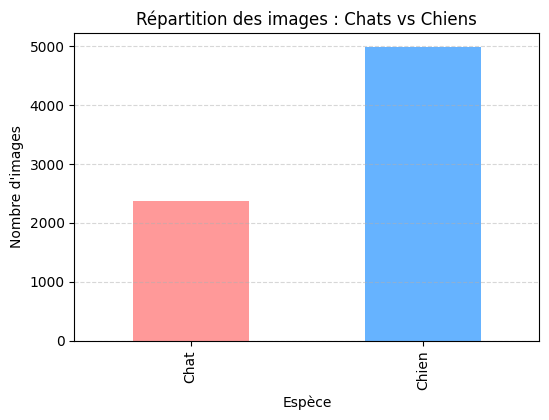

In [7]:
plt.figure(figsize=(6,4))
species_counts.plot(kind="bar", color=colors)
plt.title("Répartition des images : Chats vs Chiens")
plt.ylabel("Nombre d'images")
plt.xlabel("Espèce")
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

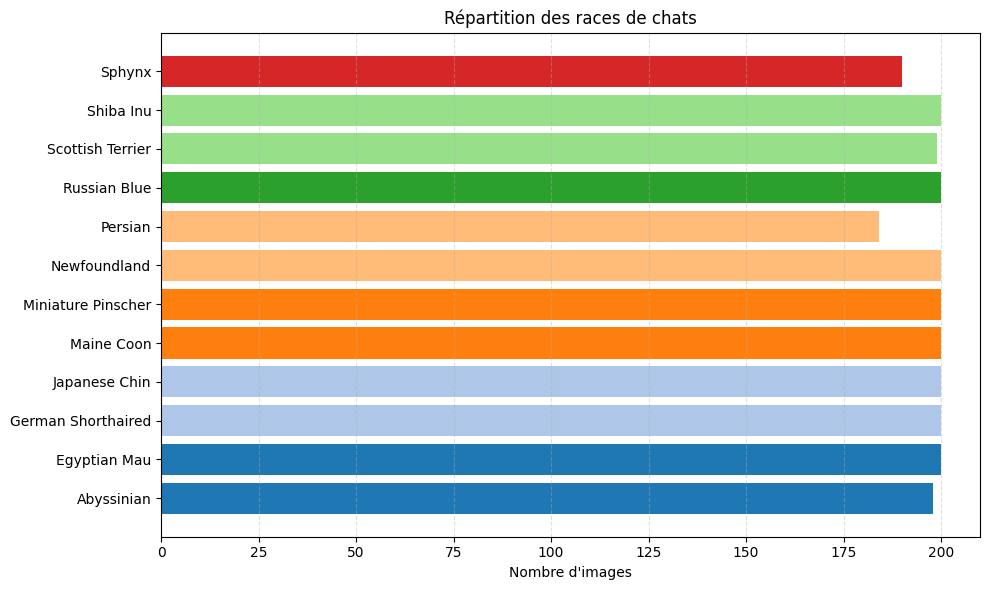

In [8]:
breed_counts = labels_df["breed_name"].value_counts().sort_index()

# Préparation couleurs
race_colors = cm.tab20(np.linspace(0, 1, 37))  # 37 couleurs

# Chats (1–12)
cat_breeds = labels_df[labels_df["category"] == 0]["breed_name"].value_counts().sort_index()
cat_colors = race_colors[:12]

plt.figure(figsize=(10, 6))
plt.barh(cat_breeds.index, cat_breeds.values, color=cat_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chats")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

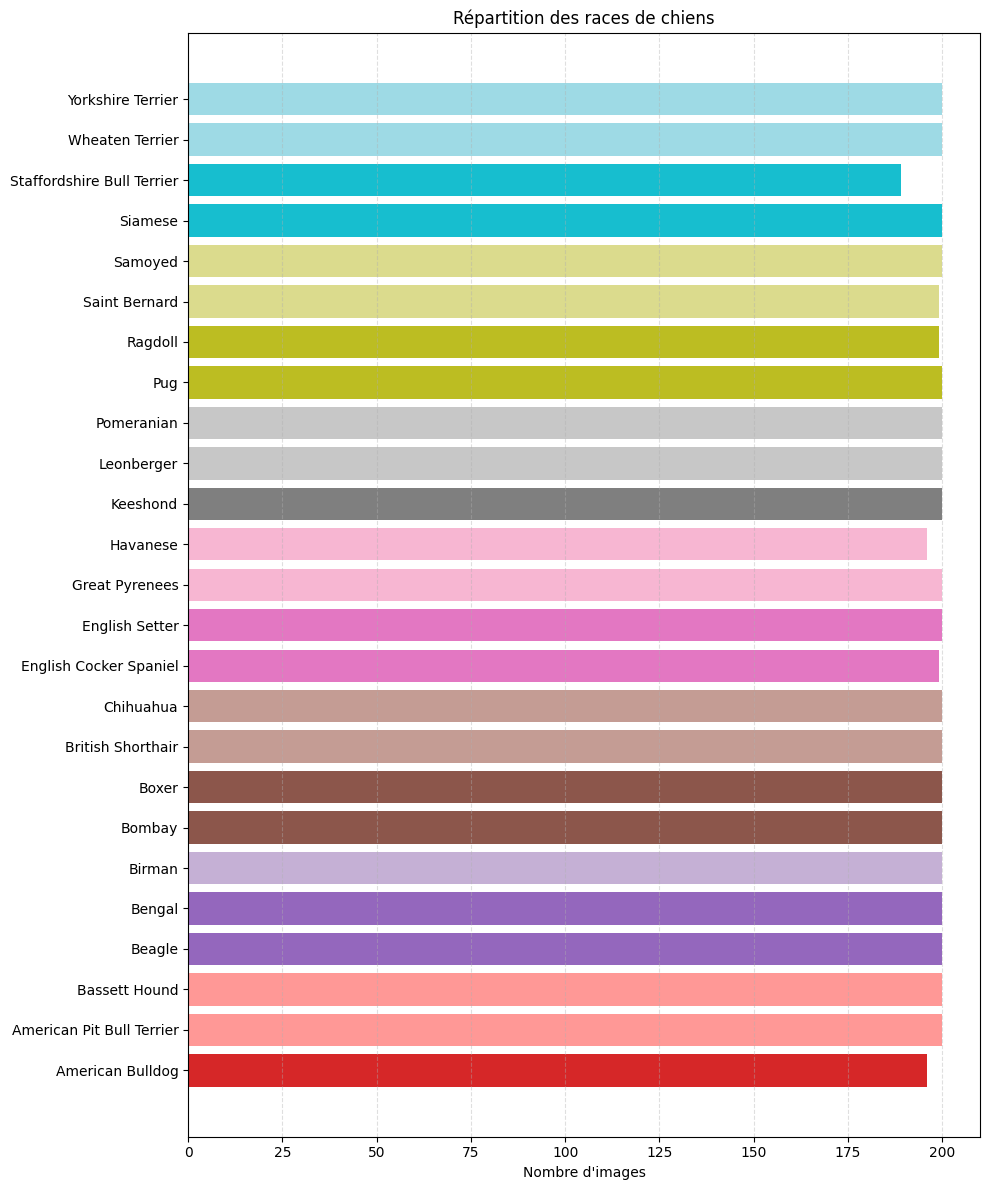

In [9]:
# Chiens (13–37)
dog_breeds = labels_df[labels_df["category"] == 1]["breed_name"].value_counts().sort_index()
dog_colors = race_colors[12:]

plt.figure(figsize=(10, 12))
plt.barh(dog_breeds.index, dog_breeds.values, color=dog_colors)
plt.xlabel("Nombre d'images")
plt.title("Répartition des races de chiens")
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche la trimap 2D pour un exemple:

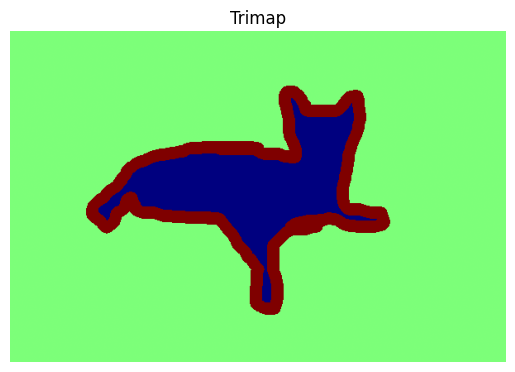

In [10]:
trimap_path = "../oxford-iiit-pet/annotations/trimaps/Abyssinian_1.png"

# Charger le trimap directement en 2D
mask = cv2.imread(trimap_path, cv2.IMREAD_UNCHANGED)
plt.imshow(mask, cmap="jet")
plt.title("Trimap")
plt.axis("off")
plt.show()



<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On récupère les masques correspondant à des images, et vérifie si les tailles correspondent:

In [11]:
image_files = sorted(os.listdir(images_path))
image_files = [f for f in os.listdir(images_path) if f.lower().endswith(".jpg")]
mask_files = sorted(os.listdir(os.path.join(annotations_path, "trimaps")))

# Récupérer les noms sans extension
image_names = [i.replace(".jpg", "") for i in image_files]
mask_names = [m.replace(".png", "") for m in mask_files]

# Filtrer les masques correspondant à des images
mask_for_images = [m for m in mask_names if m in image_names]

print("Nombre de masques correspondant à des images :", len(mask_for_images))

Nombre de masques correspondant à des images : 7390


In [12]:
size_mismatches = []

for img_file in image_files:
    img_name = img_file.replace(".jpg", "")
    mask_file = img_name + ".png"

    img = Image.open(os.path.join(images_path, img_file))
    mask = Image.open(os.path.join(annotations_path, "trimaps", mask_file))

    if img.size != mask.size:
        size_mismatches.append((img_file, img.size, mask.size))

print(f"Problèmes de dimensions : {len(size_mismatches)}")
if size_mismatches:
    for m in size_mismatches[:10]:
        print(m)

Problèmes de dimensions : 0


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On vérifie ici que tous les masques sont valides:

In [13]:
invalid_mask_values = []

mask_path = os.path.join(annotations_path, "trimaps")

# Filtrer uniquement les vrais fichiers PNG
mask_files = [f for f in os.listdir(mask_path) 
              if f.lower().endswith(".png") and not f.startswith("._")]

print(f"Nombre de masques valides : {len(mask_files)}")

for mask_file in mask_files:
    mask = np.array(Image.open(os.path.join(mask_path, mask_file)))
    unique_vals = np.unique(mask)

    # Le dataset utilise les valeurs 1, 2, 3
    if not set(unique_vals).issubset({1, 2, 3}):
        invalid_mask_values.append((mask_file, unique_vals))

print(f"Masques avec valeurs incorrectes : {len(invalid_mask_values)}")
if invalid_mask_values:
    for m in invalid_mask_values[:5]:
        print(m)

Nombre de masques valides : 7390
Masques avec valeurs incorrectes : 0


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On définit ici de quoi afficher l'image et son masque côte à côte

In [14]:
def show_image_with_mask(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    plt.figure(figsize=(10,5))

    # Afficher image
    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title("Image")
    plt.axis("off")

    # Afficher masque (couleurs distinctes)
    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap="jet", alpha=0.9)
    plt.title("Masque (trimap)")
    plt.axis("off")

    plt.show()

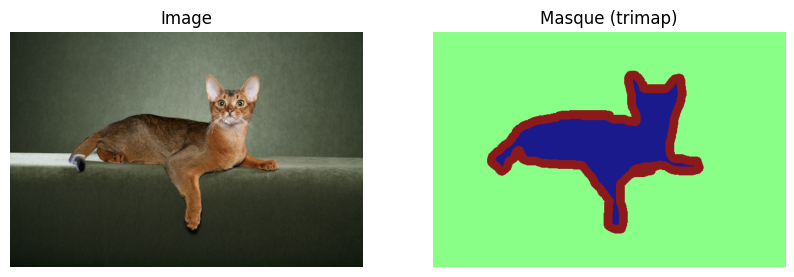

In [15]:
show_image_with_mask("Abyssinian_1")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Ainsi que la superposition des deux:

In [16]:
def show_overlay(image_name):
    img_path = os.path.join(images_path, image_name + ".jpg")
    mask_path = os.path.join(annotations_path, "trimaps", image_name + ".png")

    img = np.array(Image.open(img_path))
    mask = np.array(Image.open(mask_path))

    # Créer un overlay coloré
    cmap = plt.get_cmap("jet")
    mask_color = cmap(mask / mask.max())[..., :3]  # ignore alpha

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.imshow(mask_color, alpha=0.4)
    plt.title("Superposition image + masque (alpha = 0.4)")
    plt.axis("off")
    plt.show()

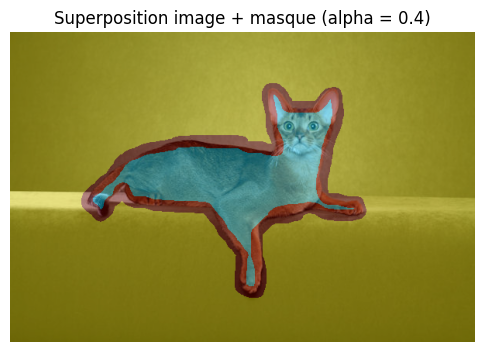

In [17]:
show_overlay("Abyssinian_1")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On explore la dimension des images pour choisir l'hyperparamètre img_size judicieusement:

In [18]:
widths, heights = [], []

for img_file in labels_df['filename']:  # tester sur un échantillon si dataset lourd
    img_path = os.path.join(images_path, img_file)
    img = Image.open(img_path)
    w, h = img.size
    widths.append(w)
    heights.append(h)

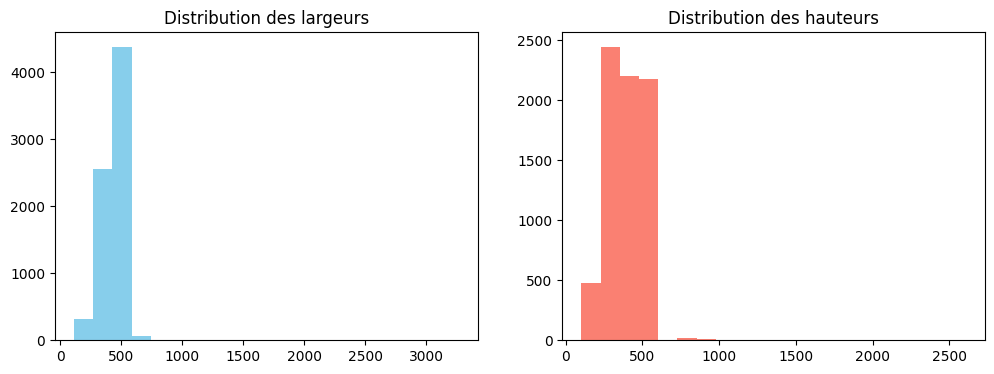

In [19]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.hist(widths, bins=20, color='skyblue')
plt.title("Distribution des largeurs")
plt.subplot(1,2,2)
plt.hist(heights, bins=20, color='salmon')
plt.title("Distribution des hauteurs")
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On définit la classe PandasDataset pour récupérer les informations contenues dedans d'une façon acceptable pour torch.

In [20]:
class PandasDataset(Dataset):
    def __init__(self, df, img_dir, skip_lines = 6, transform=None, label_col="label_enc"):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["filename"])
        label = int(row[self.label_col])   # label déjà entier

        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, torch.tensor(label, dtype=torch.long)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On créé une fonction pour afficher les informations d'entrainement de chacun de nos modèles.

In [21]:
def plot_training(nb_epochs,training_info):

    plt.figure(figsize=(12, 5))

    # Courbe de Loss (Train)
    plt.subplot(1, 2, 1)
    plt.plot(range(1, nb_epochs+1), training_info["history_train_loss"], label='Train Loss', color='blue', marker='o')
    plt.plot(range(1, nb_epochs+1), training_info["history_val_loss"], label='Val Loss', color='green', marker='o')
    plt.title('Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Courbe d'Accuracy (Validation)
    plt.subplot(1, 2, 2)
    plt.plot(range(1, nb_epochs+1), training_info["history_train_acc"], label='Train Accuracy', color='blue', marker='o')
    plt.plot(range(1, nb_epochs+1), training_info["history_val_acc"], label='Val Accuracy', color='green', marker='o')
    plt.title('Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy (%)')
    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()

<div id="20"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
2. Classification binaire

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
A décommenter et exécuter pour vider le cache de ce qui ne nous sert plus et éviter une saturation quelconque.

In [61]:
"""
del model
del train_loader, test_loader
"""
gc.collect()
torch.cuda.empty_cache()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On définit ici notre CNN et on l'entraîne:

In [62]:
# --- Hyperparamètres ---
img_size = 200
batch_size = 128 #Réduire la taille de batch en fonction de la CGU
epochs = 15
learning_rate = 0.001
val_split = 0.2  # 20% pour validation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Transformations des images ---
transform_ourCNN = transforms.Compose([
    transforms.Resize((img_size, img_size)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
])


# --- Chargement du dataset et split ---
train_dataset = PandasDataset(train_val_df, '../oxford-iiit-pet/images', transform = transform_ourCNN, label_col = "category")
test_dataset = PandasDataset(test_df, '../oxford-iiit-pet/images', transform = transform_ourCNN, label_col = "category")

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

# --- Définition du CNN ---
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv_layers = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2),
            
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2,2)
        )
        self.fc_layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*(img_size//8)*(img_size//8), 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512,1),
            nn.Sigmoid()
        )
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc_layers(x)
        return x

model = SimpleCNN().to(device)

# --- Perte et optimiseur ---
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

#Listes pour les courbes
train_loss = []
test_loss = []
train_acc = []
test_acc = []

# --- Entraînement ---
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    running_corrects = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (outputs >= 0.5).float()
        running_corrects += torch.sum(preds == labels.data)

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc.item())

    tqdm.write(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    #print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    # --- Évaluation sur validation ---
    model.eval()
    test_corrects = 0
    with torch.no_grad():
        loop = tqdm(test_loader, total=len(test_loader), desc="Testing")
        loss = 0.0
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            outputs = model(inputs)
            loss += criterion(outputs, labels).item() * inputs.size(0)
            preds = (outputs >= 0.5).float()
            test_corrects += torch.sum(preds == labels.data)

    test_acc.append((test_corrects.double() / len(test_loader.dataset)).item())
    test_loss.append(loss/len(test_loader.dataset))
    tqdm.write(f"Test Accuracy: {test_acc[-1]:.4f}")

#Dictionnaire des infos d'entrainement
training_info_CNN = {
        'history_train_loss': train_loss,
        'history_val_loss': test_loss,
        'history_train_acc': train_acc,
        'history_val_acc': test_acc,
        'total_epochs': epochs
    }
 
# --- Sauvegarde du modèle ---
torch.save(model.state_dict(), 'cat_dog_cnn.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Test: 2205 images


Epoch [1/15]: 100%|██████████| 41/41 [00:26<00:00,  1.57it/s]


Epoch 1/15 | Loss: 0.7118 | Acc: 0.6553


Testing: 100%|██████████| 18/18 [00:08<00:00,  2.03it/s]


Test Accuracy: 0.6776


...

Test Accuracy: 0.8000


Epoch [15/15]: 100%|██████████| 41/41 [00:24<00:00,  1.64it/s]


Epoch 15/15 | Loss: 0.2237 | Acc: 0.9125


Testing: 100%|██████████| 18/18 [00:09<00:00,  1.95it/s]


Test Accuracy: 0.8041
Modèle sauvegardé !


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche nos métriques.

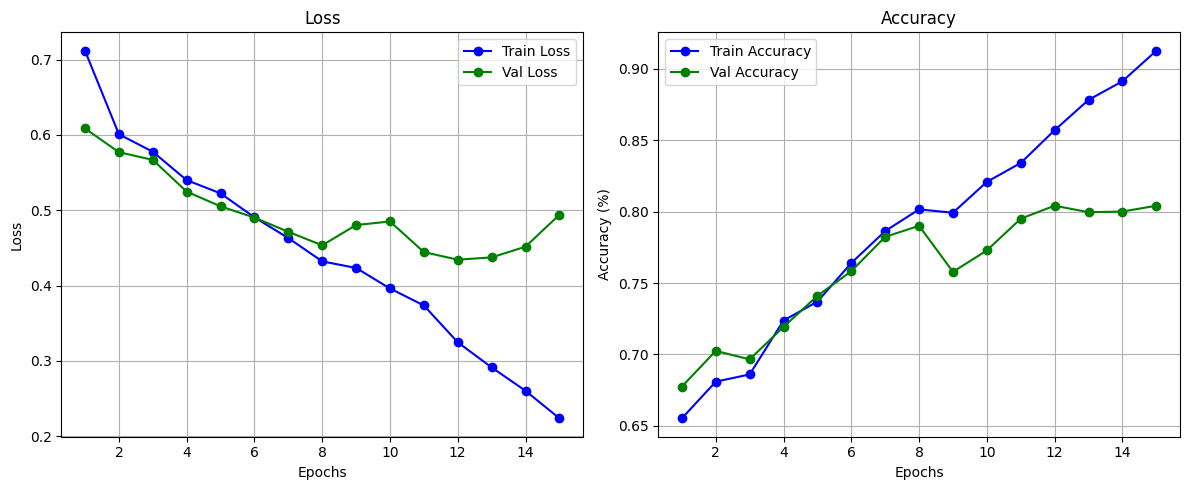

In [63]:
plot_training(epochs, training_info_CNN)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On s'arrête à 15 époques car on voit que la perte et l'accuracy sur le jeu de test ne diminue/augmente plus alors que cela continue pour le jeu d'entraînement. On a 80% de précision sur le jeu de test ce qui est correct mais pas vraiment satisfaisant pour un problème de classification à 2 classes. 
On peut afficher un échantillon de nos prédictions une fois l'entraînement terminé.

In [25]:
def show_val_predictions(model, val_loader, class_names=["Cat", "Dog"], num_images=8, device="cpu"):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Prédiction
            outputs = model(images)
            preds = (outputs > 0.5).long().view(-1)  # pour BCEWithLogitsLoss

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):

                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].permute(1, 2, 0).numpy()
                img = (img * 0.5 + 0.5).clip(0, 1)  # dénormalisation

                plt.subplot(2, num_images//2, images_shown + 1)
                plt.imshow(img)
                plt.axis("off")

                true_lbl = class_names[int(labels[i].item())]
                pred_lbl = class_names[int(preds[i].item())]

                color = "green" if true_lbl == pred_lbl else "red"

                plt.title(f"T:{true_lbl} / P:{pred_lbl}", color=color, fontsize=10)

                images_shown += 1

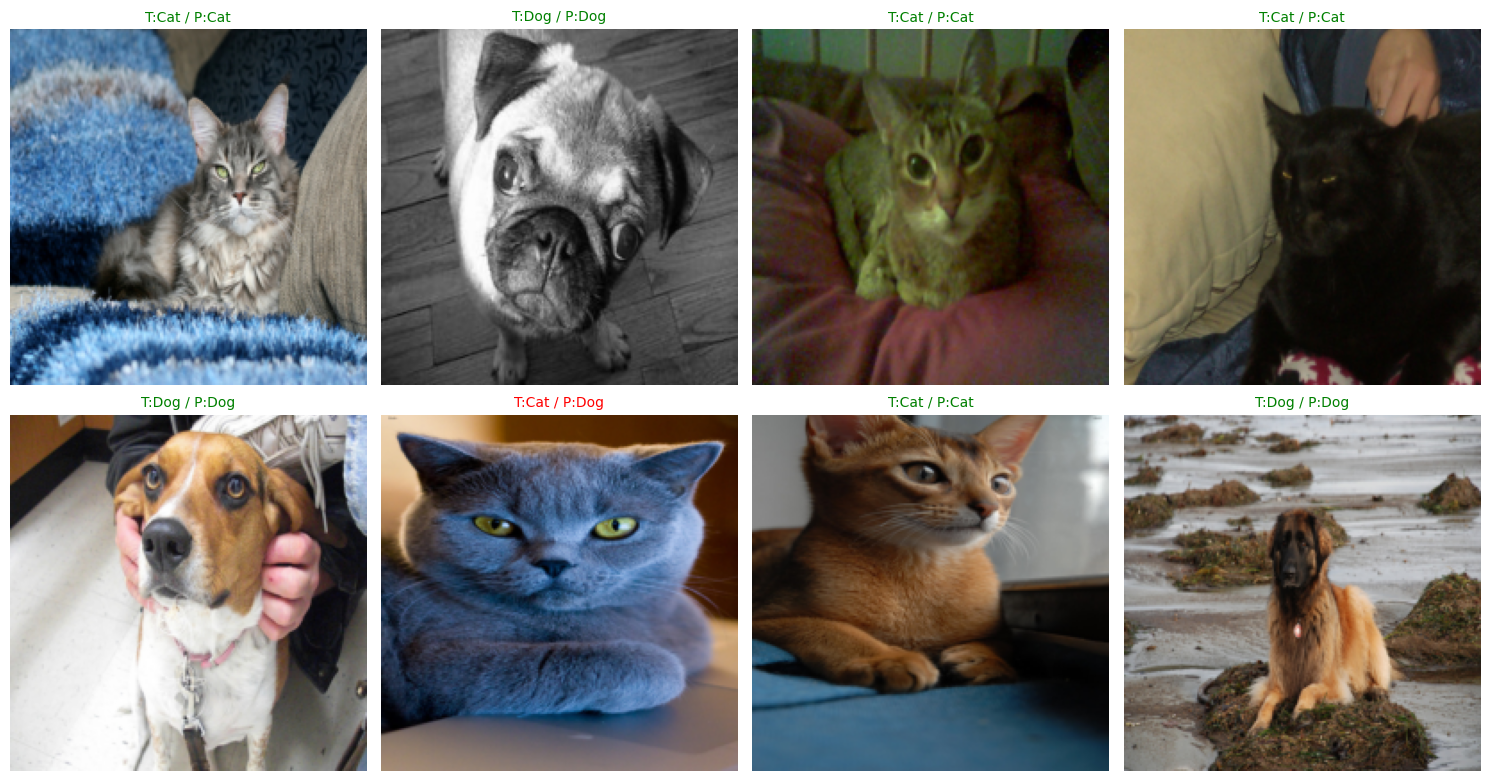

In [26]:
show_val_predictions(model, test_loader, class_names=["Cat", "Dog"], device=device)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Pour obtenir un modèle plus précis, on va utiliser un réseau pré-entrainé. On va faire du Transfer Learning en ajoutant une couche de classification au réseau VGG16 pour l'appliquer à notre problème de classification chat/chien. On décide de ne pas faire de Fine-Tuning car la tâche est suffisament simple pour espérer que le Transfer Learning donne des résultats suffisament bons.

In [64]:
# --- Hyperparamètres ---
img_size = 224
epochs = 10
learning_rate = 0.001
val_split = 0.2  # 20% pour validation
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Dataset personnalisé ---
print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

model_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)

# Geler les couches convolutionnelles
for param in model_vgg.features.parameters():
    param.requires_grad = False

# Remplacer le classifieur final
num_features = model_vgg.classifier[6].in_features
model_vgg.classifier[6] = nn.Linear(num_features, 1)  # 1 sortie pour binaire
model_vgg = model_vgg.to(device)

criterion = nn.BCEWithLogitsLoss()  # sortie 1 neurone
optimizer = optim.Adam(model_vgg.classifier[6].parameters(), lr=1e-4)

#Listes pour les courbes
train_loss = []
test_loss = []
train_acc = []
test_acc = []

for epoch in range(epochs):
    model_vgg.train()
    running_loss = 0.0
    running_corrects = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()

        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = (torch.sigmoid(outputs) > 0.5).float()
        running_corrects += torch.sum(preds == labels.data)

        loop.set_postfix(loss=running_loss/((loop.n+1)*batch_size),
                         acc=(running_corrects.double()/((loop.n+1)*batch_size)).item())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc.item())
    tqdm.write(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")
    
    # --- Évaluation sur validation ---
    model_vgg.eval()
    test_corrects = 0
    with torch.no_grad():
        loss = 0.0
        loop = tqdm(test_loader, total=len(test_loader), desc="Testing")
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device).unsqueeze(1).float()
            outputs = model_vgg(inputs)
            loss += criterion(outputs, labels).item()* inputs.size(0)
            preds = (torch.sigmoid(outputs) > 0.5).float()
            test_corrects += torch.sum(preds == labels.data)

    test_loss.append(loss/len(test_loader.dataset))
    test_acc.append((test_corrects.double() / len(test_loader.dataset)).item())
    print(f"Test Accuracy: {test_acc[-1]:.4f}")
    
# Sauvegarde des infos d'entrainement
training_info_VGG = {    
        'history_train_loss': train_loss,
        'history_val_loss': test_loss,
        'history_train_acc': train_acc,
        'history_val_acc': test_acc,
        'total_epochs': epochs
    }

# Sauvegarde du modèle
torch.save(model_vgg.state_dict(), 'vgg16_cat_dog.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Test: 2205 images


Epoch [1/10]: 100%|██████████| 41/41 [00:32<00:00,  1.26it/s, acc=0.827, loss=0.422]


Epoch 1/10 | Loss: 0.4302 | Acc: 0.8433


Testing: 100%|██████████| 18/18 [00:13<00:00,  1.34it/s]


Test Accuracy: 0.9601


...

Test Accuracy: 0.9850


Epoch [10/10]: 100%|██████████| 41/41 [00:32<00:00,  1.24it/s, acc=0.962, loss=0.0605]


Epoch 10/10 | Loss: 0.0618 | Acc: 0.9819


Testing: 100%|██████████| 18/18 [00:13<00:00,  1.31it/s]


Test Accuracy: 0.9846
Modèle sauvegardé !


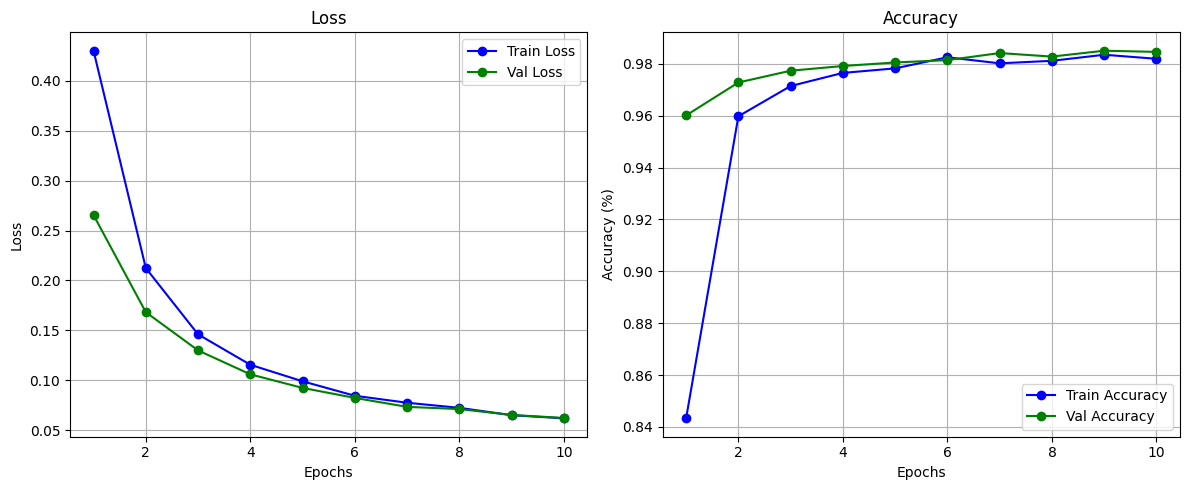

In [65]:
plot_training(epochs, training_info_VGG)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On atteint des plateaux pour la loss et l'accuracy de notre modèle à la fois sur les jeux d'entraînement et de test. On a donc atteint la performance maximale de notre modèle sans overfitting car le modèle est même légèrement plus performant sur le jeu de test que le jeu d'entrainement. On atteint une accuracy de 98% ce qui beaucoup plus satisfaisant que notre modèle from scratch.

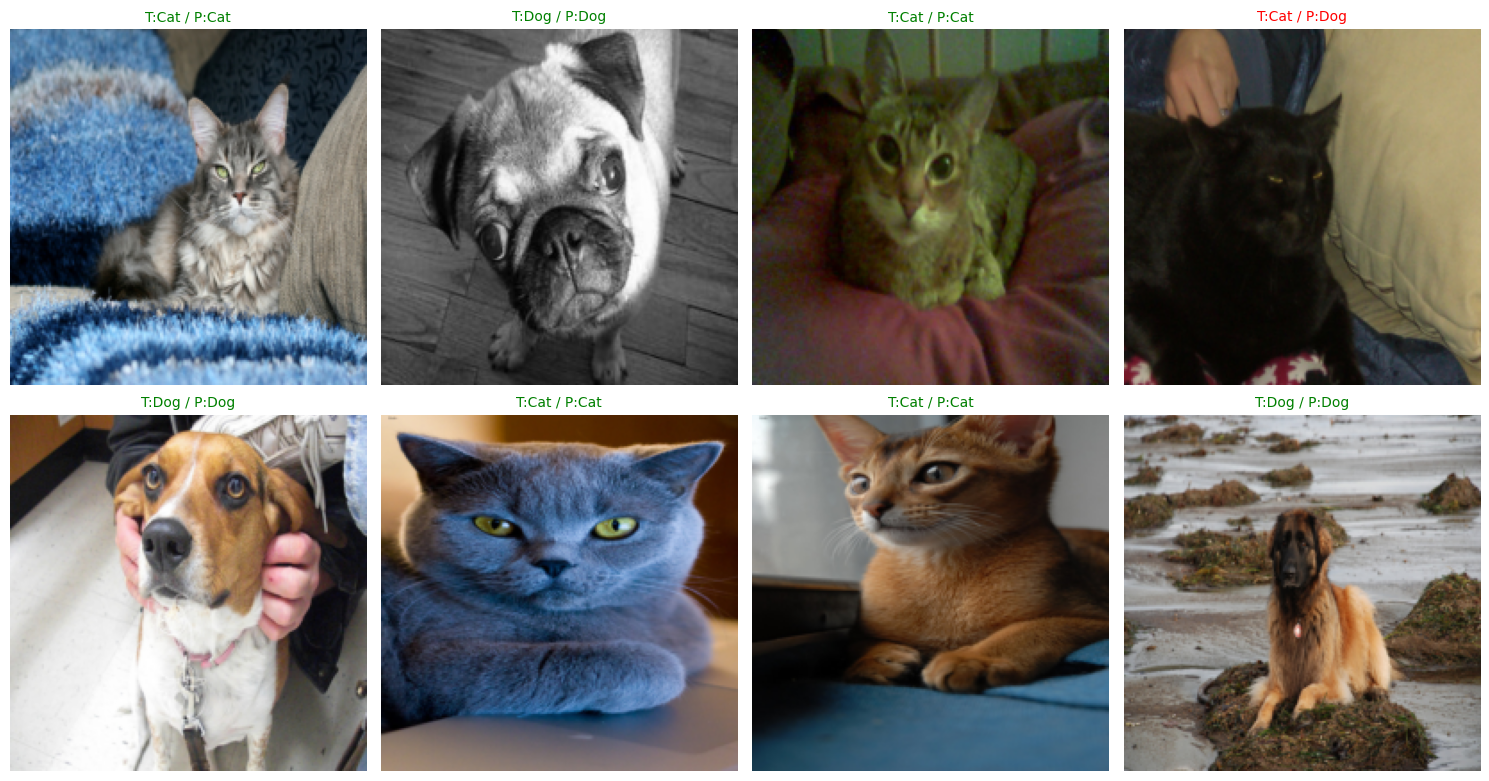

In [29]:
show_val_predictions(model_vgg, test_loader, class_names=["Cat", "Dog"], device=device)

In [71]:
from torchsummary import summary
summary(model,(200,200,3))

RuntimeError: Given groups=1, weight of size [32, 3, 3, 3], expected input[2, 200, 200, 3] to have 3 channels, but got 200 channels instead

<div id="30"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
3. Classification fine

In [30]:
train_val_df["label_enc"] = train_val_df["CLASS-ID"] - 1
test_df["label_enc"] = test_df["CLASS-ID"] - 1

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On supprime nos précédents loader qui ne serviront plus ainsi que le cache du GPU.

In [31]:
del model_vgg
gc.collect()
torch.cuda.empty_cache()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On va comme avant fine tune le réseau pre-train VGG16 en ajoutant une couche Linéaire à la fin qu'on va optimiser pour retrouver nos classes de chats et chiens.

In [32]:
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

batch_size = 64 

vgg16_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

vgg16_train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=45),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std =[0.229, 0.224, 0.225],
    )
])

train_dataset = PandasDataset(train_val_df, '../oxford-iiit-pet/images', transform=vgg16_train_transforms)
test_dataset   = PandasDataset(test_df, '../oxford-iiit-pet/images',  transform=vgg16_transforms)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader   = DataLoader(test_dataset, batch_size=batch_size)

# --- Hyperparamètres ---
img_size = 224
epochs = 20
learning_rate = 0.001
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# --- Dataset personnalisé ---
print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

model_vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# Geler les couches convolutionnelles
for param in model_vgg.features.parameters():
    param.requires_grad = False

# Remplacer le classifieur final
num_features = model_vgg.classifier[6].in_features
num_classes = train_val_df["label_enc"].nunique()
model_vgg.classifier[6] = nn.Linear(num_features, num_classes)
model_vgg = model_vgg.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_vgg.classifier[6].parameters(), lr=1e-4)

torch.cuda.empty_cache()

#Listes pour les courbes
train_loss = []
train_acc = []
test_loss = []
test_acc = []

for epoch in range(epochs):
    model_vgg.train()
    running_loss = 0.0
    running_corrects = 0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, labels in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model_vgg(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        preds = outputs.argmax(dim=1)
        running_corrects += torch.sum(preds == labels.data)

        loop.set_postfix(loss=running_loss/((loop.n+1)*train_loader.batch_size),
                         acc=(running_corrects.double()/((loop.n+1)*train_loader.batch_size)).item())

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = running_corrects.double() / len(train_loader.dataset)
    train_loss.append(epoch_loss)
    train_acc.append(epoch_acc.item())
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

    model_vgg.eval()
    val_corrects = 0
    loss = 0.0
    with torch.no_grad():
        loop = tqdm(test_loader, total=len(test_loader), desc=f"Testing")
        for inputs, labels in loop:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model_vgg(inputs)
            loss += criterion(outputs, labels).item() * inputs.size(0)
            preds = outputs.argmax(dim=1)
            val_corrects += torch.sum(preds == labels.data)

    test_loss.append(loss/len(test_loader.dataset))
    test_acc.append((val_corrects.double() / len(test_loader.dataset)).item())
    print(f"Test Accuracy: {test_acc[-1]:.4f}")

# Sauvegarde des infos d'entrainement
training_info_VGG_race = {    
        'history_train_loss': train_loss,
        'history_val_loss': test_loss,
        'history_train_acc': train_acc,
        'history_val_acc': test_acc,
        'total_epochs': epochs
    }

torch.save(model_vgg.state_dict(), 'vgg16_cat_dog_race.pth')
print("Modèle sauvegardé !")

cuda
Train: 5144 images | Test: 2205 images


Epoch [1/20]: 100%|██████████| 81/81 [00:37<00:00,  2.18it/s, acc=0.338, loss=2.61] 


Epoch 1/20 | Loss: 2.6344 | Acc: 0.3406


Testing: 100%|██████████| 35/35 [00:15<00:00,  2.29it/s]


Test Accuracy: 0.7814


...

Test Accuracy: 0.9011


Epoch [20/20]: 100%|██████████| 81/81 [00:38<00:00,  2.13it/s, acc=0.848, loss=0.467]


Epoch 20/20 | Loss: 0.4706 | Acc: 0.8550


Testing: 100%|██████████| 35/35 [00:15<00:00,  2.25it/s]


Test Accuracy: 0.9002
Modèle sauvegardé !


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche nos métriques.

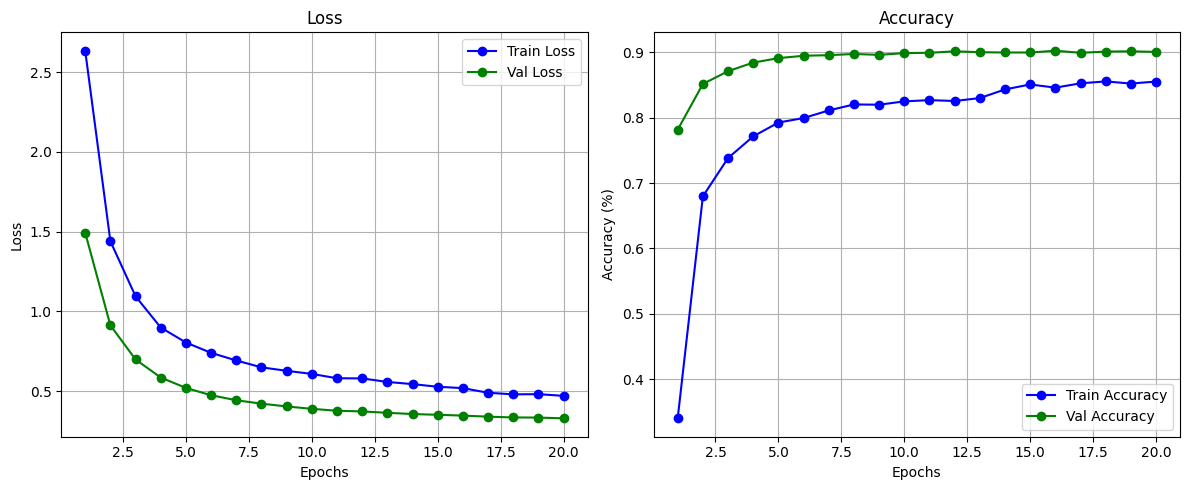

In [33]:
plot_training(epochs, training_info_VGG_race)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On atteint des plateaux pour la loss et l'accuracy de notre modèle à la fois sur les jeux d'entraînement et de test. On a donc atteint la performance maximale de notre modèle sans overfitting car le modèle est même plus performant sur le jeu de test que le jeu d'entrainement. On atteint une accuracy de 90% ce qui est extrêmement satisfaisant pour un problème de classification à 37 classes.

In [34]:
test_df['breed_name'] = test_df['filename'].apply(lambda x: "_".join(x.split("_")[:-1]))
breed_names = test_df["breed_name"].unique()[np.argsort(test_df['label_enc'].unique())]

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche quelques prédictions de notre modèle.

In [35]:
def show_val_predictions_race(model, val_loader, race_names, num_images=8, device="cpu"):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(15, 8))

    with torch.no_grad():
        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            # Prédiction
            outputs = model(images)
            preds = outputs.argmax(dim=1).long().view(-1) 
            print(preds)

            images = images.cpu()
            labels = labels.cpu()
            preds = preds.cpu()

            for i in range(images.size(0)):

                if images_shown >= num_images:
                    plt.tight_layout()
                    plt.show()
                    return

                img = images[i].permute(1, 2, 0).numpy()
                img = (img * 0.5 + 0.5).clip(0, 1)  # dénormalisation

                plt.subplot(2, num_images//2, images_shown + 1)
                plt.imshow(img)
                plt.axis("off")

                true_lbl = race_names[int(labels[i].item())]
                pred_lbl = race_names[int(preds[i].item())]

                color = "green" if true_lbl == pred_lbl else "red"

                plt.title(f"T:{true_lbl} / P:{pred_lbl}", color=color, fontsize=10)

                images_shown += 1

tensor([11, 25,  5,  7,  4,  9,  0, 19, 23, 23, 24, 11, 14, 24, 26, 26, 27, 21,
        21, 14,  4, 36,  1,  4,  7, 27, 24,  6,  4, 30, 27,  6, 27, 31, 18,  1,
         0, 23, 27, 15, 24, 35,  5, 11, 14,  9, 14, 19,  7,  2, 13, 34, 21, 13,
        27, 32, 35, 15, 33, 35, 12, 32,  1,  1], device='cuda:0')


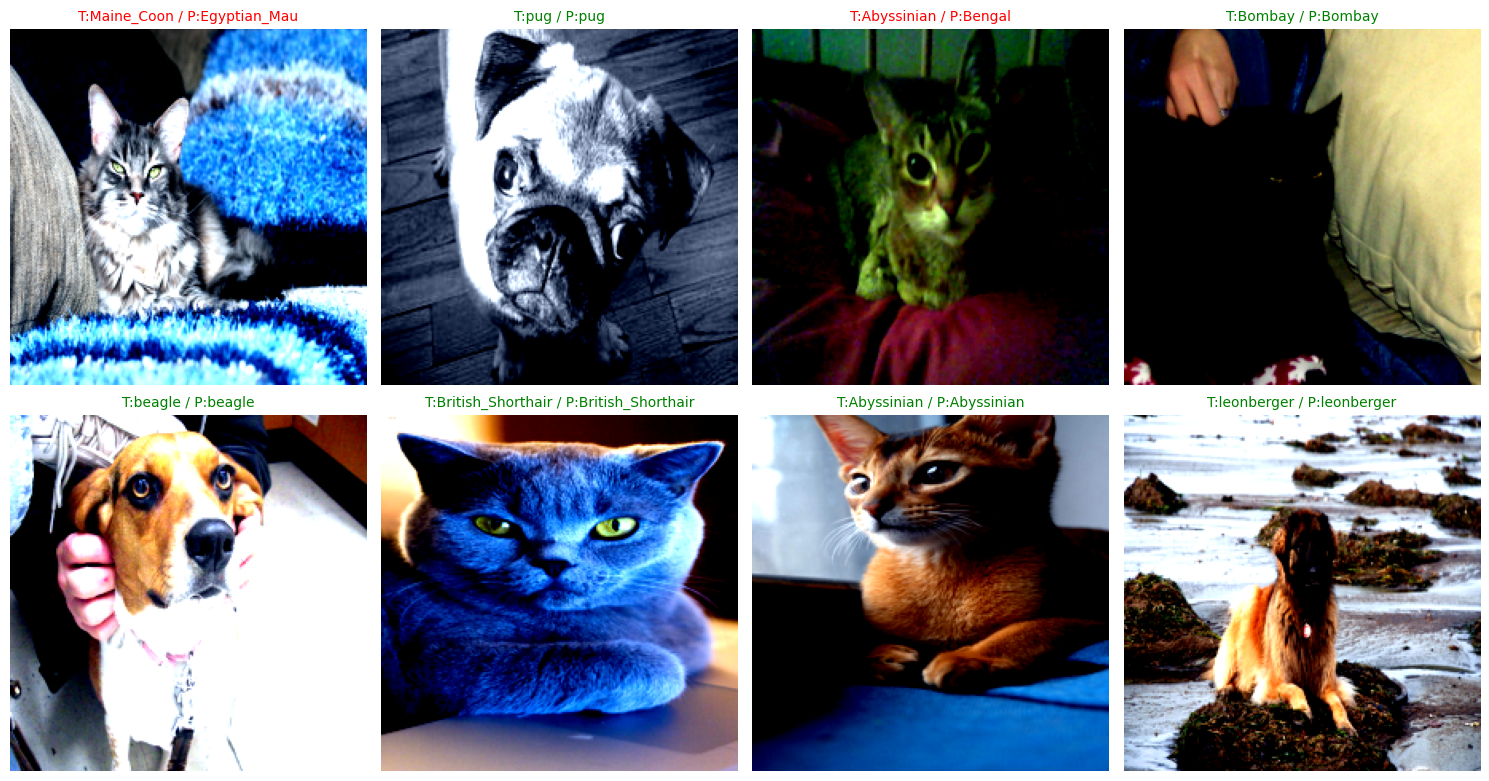

In [36]:
show_val_predictions_race(model_vgg, test_loader, race_names=breed_names, device=device)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On observe en effet que notre modèle se trompe de temps en temps. Pour essayer de comprendre pourquoi, on va afficher la matrice de confusion.

In [37]:
model_vgg.eval()

true_lbl = np.empty(len(test_df), dtype='<U50')
pred_lbl = np.empty(len(test_df), dtype='<U50')
index = 0

with torch.no_grad():
    for images, labels in test_loader:
    
        images = images.to(device)
        labels = labels.to(device)
    
        # Prédiction
        outputs = model_vgg(images)
        preds = outputs.argmax(dim=1).long().view(-1) 

        images = images.cpu()
        labels = labels.cpu()
        preds = preds.cpu()
    
        for i in range(images.size(0)):
    
            true_lbl[index] = breed_names[int(labels[i].item())]
            pred_lbl[index] = breed_names[int(preds[i].item())]
    
            index += 1

print(true_lbl)
print(pred_lbl)

['Maine_Coon' 'pug' 'Abyssinian' ... 'Russian_Blue' 'miniature_pinscher'
 'chihuahua']
['Egyptian_Mau' 'pug' 'Bengal' ... 'Russian_Blue' 'miniature_pinscher'
 'chihuahua']


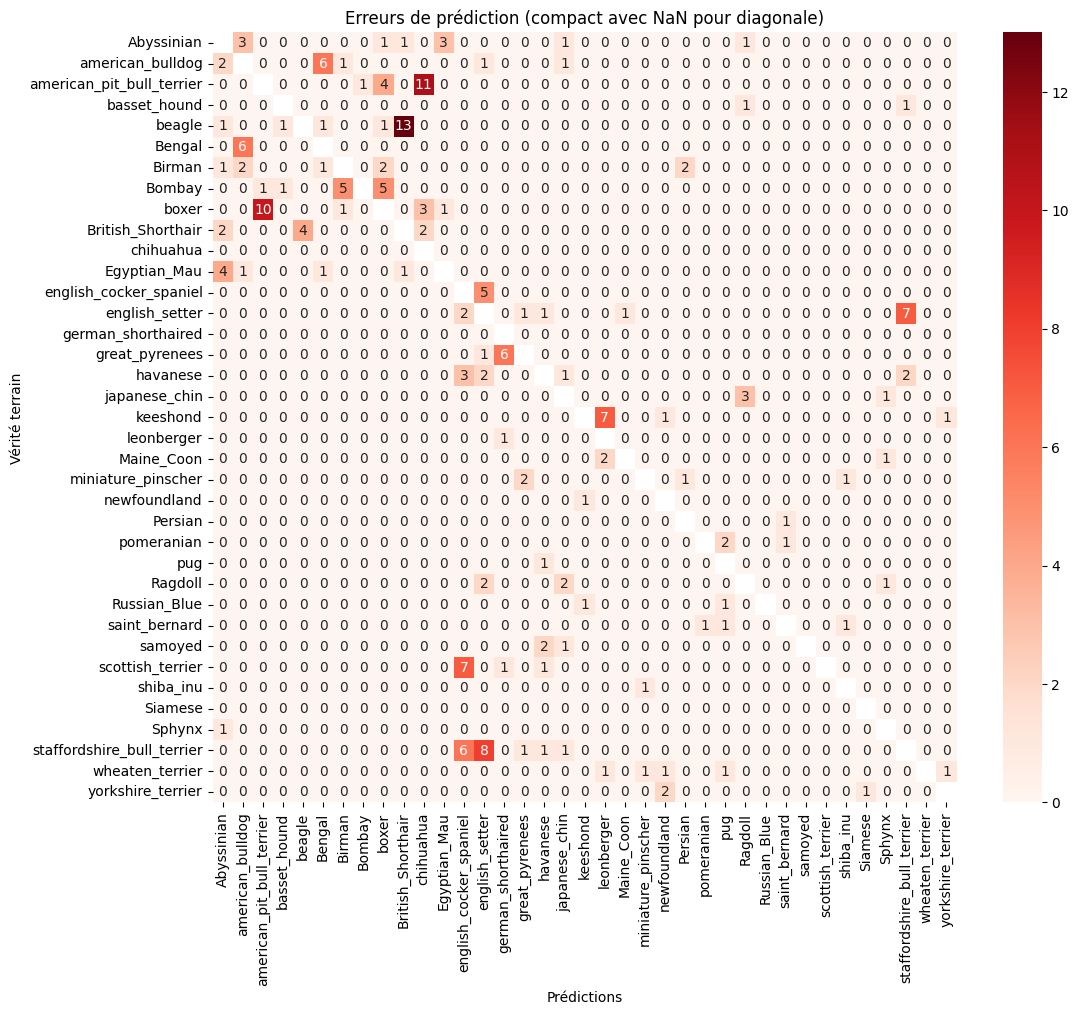

In [38]:
from sklearn.metrics import confusion_matrix

# Calcul de la matrice de confusion
cm = confusion_matrix(true_lbl, pred_lbl)

# Créer un DataFrame complet avec les noms de races
cm_df = pd.DataFrame(cm, index=breed_names, columns=breed_names)

# Remplacer les bonnes prédictions par NaN pour n'afficher que les erreurs
cm_errors = cm_df.mask(np.eye(len(cm_df), dtype=bool))

# Affichage
plt.figure(figsize=(12,10))
sns.heatmap(cm_errors, annot=True, fmt=".0f", cmap="Reds", cbar=True)
plt.xlabel("Prédictions")
plt.ylabel("Vérité terrain")
plt.title("Erreurs de prédiction (compact avec NaN pour diagonale)")
plt.show()


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Même si la confusion la plus observé (entre Beagle et British Shorthaired) se fait entre une race de chien et une race de chat. On observe majoritairement des confusions entre race de la même espèce. Ce modèle est aussi performant que le précédent pour classifier les espèces (chat ou chien). Cela nous conforte dans le fait de pouvoir directement entrainer notre modèle à trouver les races plutôt que de d'abord classer l'espèce puis les races parmi l'espèce.
De la matrice de confusion, on ne trouve pas de biais évident (races de même taille et même couleur). 

<div id="40"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
4. Segmentation des animaux

In [39]:
img_size = 160

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On va créer une nouvelle classe de dataset pour stocker nos trimaps avec nos images et les labels.

In [40]:
class SegmentationDataset(Dataset):
    def __init__(self, img_paths, mask_paths, img_size, species, races):
        self.img_paths = img_paths
        self.mask_paths = mask_paths
        self.img_size = img_size
        self.species = species
        self.races = races

        self.img_transform = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])
        ])

        self.mask_transform = transforms.Compose([
            transforms.Resize((img_size, img_size), interpolation=Image.NEAREST)
        ])

    def __getitem__(self, idx):
        img = Image.open(self.img_paths[idx]).convert("RGB")
        mask = Image.open(self.mask_paths[idx])

        # IMPORTANT : appliquer la même flip pour image et mask
        if random.random() < 0.5:
            img = TF.hflip(img)
            mask = TF.hflip(mask)

        img = self.img_transform(img)
        mask = self.mask_transform(mask)
        mask_array = np.array(mask, dtype=np.int64)-1
        mask = torch.as_tensor(mask_array, dtype=torch.long)
        specie_tensor = torch.as_tensor(self.species[idx], dtype=torch.long)
        race_tensor = torch.as_tensor(self.races[idx], dtype=torch.long)
        
        return img, mask, specie_tensor, race_tensor

    def __len__(self):
        return len(self.img_paths)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On rajoute la couche DoubleConv, pour enchaîner deux convolutions, ce qui est nécessaire pour une architecture U-Net.

In [41]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On récupère ici simplement l'architecture U-Net présentée à la diapositive 40 du cours. U-Net est une architecture adapté à la segmentation car la sortie sera une trimap (image) et non pas un vecteur de scalaire comme les architectures précédentes.

In [42]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=3):
        super().__init__()

        # Encoder
        self.down1 = DoubleConv(in_channels, 64, 3)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128,3)
        self.pool2 = nn.MaxPool2d(2)
        self.down3 = DoubleConv(128, 256,3)
        self.pool3 = nn.MaxPool2d(2)
        self.down4 = DoubleConv(256, 512,3)
        self.pool4 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = DoubleConv(512, 1024,3)

        # Decoder
        self.up4 = nn.ConvTranspose2d(1024, 512, 2, stride=2)
        self.conv4 = DoubleConv(1024, 512,3)
        self.up3 = nn.ConvTranspose2d(512, 256, 2, stride=2)
        self.conv3 = DoubleConv(512, 256,3)
        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128,3)
        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64,3)

        # Output
        self.out = nn.Conv2d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # Encoder
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)

        c3 = self.down3(p2)
        p3 = self.pool3(c3)

        c4 = self.down4(p3)
        p4 = self.pool4(c4)

        # Bottleneck
        bn = self.bottleneck(p4)

        # Decoder
        u4 = self.up4(bn)
        u4 = torch.cat([u4, c4], dim=1)
        c5 = self.conv4(u4)

        u3 = self.up3(c5)
        u3 = torch.cat([u3, c3], dim=1)
        c6 = self.conv3(u3)

        u2 = self.up2(c6)
        u2 = torch.cat([u2, c2], dim=1)
        c7 = self.conv2(u2)

        u1 = self.up1(c7)
        u1 = torch.cat([u1, c1], dim=1)
        c8 = self.conv1(u1)

        return self.out(c8)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Définition de l'Intersection over Union (IoU) et du Dice Score pour évaluer la performance du modèle U-Net

In [43]:
def IoU(pred, target,num_classes, eps=1e-6):
    # 1. Traitement de la prédiction
    # pred: [B, C, H, W]*
    pred = torch.softmax(pred, dim=1) 
    
    # 2. Obtenir la prédiction finale (indices de classe: 0, 1, 2)
    # pred_labels: [B, H, W]
    pred_labels = torch.argmax(pred, dim=1).long()
    
    # 3. Initialiser la liste pour les scores par classe
    iou_per_class = []

    for c in range(num_classes):
        
        # Créer les masques binaires (True/False ou 1/0)
        # gt_mask: [B, H, W] où 1 si pixel == c, 0 sinon
        gt_mask = (target == c).float() 
        # pred_mask: [B, H, W] où 1 si prédit == c, 0 sinon
        pred_mask = (pred_labels == c).float() 

        # Calcul de l'intersection et de l'union
        # Intersection: True Positive (TP)
        intersection = (pred_mask * gt_mask).sum(dim=[1, 2])
        
        # Union: (TP + FP + FN)
        union = pred_mask.sum(dim=[1, 2]) + gt_mask.sum(dim=[1, 2]) - intersection
        
        # IoU pour cette classe
        iou = (intersection + eps) / (union + eps)
        iou_per_class.append(iou)

    # 5. Retourner la moyenne des IoU sur toutes les classes (Macro Average)
    return torch.stack(iou_per_class).transpose(0, 1).mean(axis=1)
    

def dice_score(pred, target, num_classes,eps=1e-6):
    # 1. Traitement de la prédiction
    # pred: [B, C, H, W]*
    pred = torch.softmax(pred, dim=1) 
    
    # 2. Obtenir la prédiction finale (indices de classe: 0, 1, 2)
    # pred_labels: [B, H, W]
    pred_labels = torch.argmax(pred, dim=1).long()
    
    # 3. Initialiser la liste pour les scores par classe
    dice_per_class = []

    for c in range(num_classes):
        
        # Créer les masques binaires (True/False ou 1/0)
        # gt_mask: [B, H, W] où 1 si pixel == c, 0 sinon
        gt_mask = (target == c).float() 
        # pred_mask: [B, H, W] où 1 si prédit == c, 0 sinon
        pred_mask = (pred_labels == c).float() 

        # Calcul de l'intersection et de l'union
        # Intersection: True Positive (TP)
        intersection = (pred_mask * gt_mask).sum(dim=[1, 2])
        
        # Union: (TP + FP + FN)
        #union = pred_mask.sum() + gt_mask.sum() - intersection
        
        # IoU pour cette classe
        dice = (2*intersection + eps) / (pred_mask.sum(dim=[1, 2]) + gt_mask.sum(dim=[1, 2]) + eps)
        dice_per_class.append(dice)

    # 5. Retourner la moyenne des IoU sur toutes les classes (Macro Average)
    return torch.stack(dice_per_class).transpose(0, 1).mean(axis=1)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Chargement du dataset, instanciation des hyperparamètres:

In [44]:
# --- Chargement du dataset et split ---
seg_dataset = SegmentationDataset(
    img_paths=labels_df['img_path'].tolist(),
    mask_paths=labels_df['mask_path'].tolist(),
    img_size=img_size,
    species=labels_df['category'].tolist(),
    races=labels_df['CLASS-ID'].tolist(),
)

# --- Hyperparamètres ---
img_size = 160
batch_size = 64 #Réduire la taille de batch en fonction de la CGU
test_split = 0.2  # 20% pour validation

test_size = int(len(seg_dataset) * test_split)
train_size = len(seg_dataset) - test_size
train_dataset, test_dataset = random_split(seg_dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Train: {len(train_dataset)} images | Test: {len(test_dataset)} images")

Train: 5880 images | Test: 1469 images


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
Entraînement du modèle:

In [ ]:
model_seg = UNet(in_channels=3, out_channels=3).to(device)
# --- Hyperparamètres ---
epochs = 25
learning_rate = 0.001

# --- Perte et optimiseur ---
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_seg.parameters(), lr=1e-3)


CHECKPOINT_PATH = 'segmentation.pth'
start_epoch = 0 


#chargement du modèle déja entrainé
if os.path.exists(CHECKPOINT_PATH):
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
    
    # Charger l'état du modèle
    model_seg.load_state_dict(checkpoint['model_state_dict'])
    print("Poids du modèle chargés avec succès.")
    
    # Charger l'état de l'optimiseur
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    print("État de l'optimiseur chargé avec succès.")

    # Reprendre l'époque de départ (si elle a été sauvegardée)
    if 'epoch' in checkpoint:
        start_epoch = checkpoint['epoch'] 
        print(f"Reprise de l'entraînement à partir de l'époque {start_epoch}.")
    else:
        print("L'époque de départ n'est pas spécifiée dans le checkpoint. Début à l'époque 0.")

else:
    print(f"Fichier {CHECKPOINT_PATH} non trouvé. Début de l'entraînement à partir de zéro.")

#Liste pour les courbes
train_loss = []
train_iou =[]
train_dice = []
test_loss = []
test_iou = []
test_dice = []

for epoch in range(start_epoch, epochs):
    model_seg.train()
    running_loss = 0.0
    running_dice = 0.0
    running_iou = 0.0

    loop = tqdm(train_loader, total=len(train_loader), desc=f"Epoch [{epoch+1}/{epochs}]")
    for inputs, masks,_,_ in loop:
        inputs, masks = inputs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model_seg(inputs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        dice = dice_score(outputs, masks,3).mean().item()
        running_dice += dice * inputs.size(0)
        iou = IoU(outputs, masks,3).mean().item()
        running_iou += iou * inputs.size(0)

        loop.set_postfix(loss=running_loss/((loop.n+1)*train_loader.batch_size),
                         iou = running_iou/((loop.n+1)*train_loader.batch_size),
                         dice = running_dice/((loop.n+1)*train_loader.batch_size))

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_iou =  running_iou / len(train_loader.dataset)
    epoch_dice = running_dice / len(train_loader.dataset)
    train_loss.append(epoch_loss)
    train_iou.append(epoch_iou)
    train_dice.append(epoch_dice)
    
    print(f"Epoch {epoch+1}/{epochs} | Loss: {epoch_loss:.4f} | IoU: {epoch_iou:.4f} | Dice: {epoch_dice:.4f}")

    model_seg.eval()
    iou = 0.0
    dice = 0.0
    loss = 0.0
    with torch.no_grad():
        loop = tqdm(test_loader, total=len(test_loader), desc=f"Testing")
        for inputs, masks,_,_ in loop:
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model_seg(inputs)
            iou +=  IoU(outputs, masks,3).sum().item()
            dice += dice_score(outputs, masks,3).sum().item()
            loss += criterion(outputs, masks).item() * inputs.size(0)

    test_iou.append(iou / len(test_loader.dataset))
    test_dice.append(dice / len(test_loader.dataset))
    test_loss.append(loss / len(test_loader.dataset))


torch.save({'model_state_dict': model_seg.state_dict(),'optimizer_state_dict': optimizer.state_dict(),'epoch': epochs,}, CHECKPOINT_PATH)

Fichier segmentation.pth non trouvé. Début de l'entraînement à partir de zéro.


Epoch [1/20]: 100%|██████████| 92/92 [02:00<00:00,  1.31s/it, dice=0.589, iou=0.469, loss=0.636]


Epoch 1/20 | Loss: 0.6364 | IoU: 0.4694 | Dice: 0.5897


Epoch [2/20]: 100%|██████████| 92/92 [01:58<00:00,  1.29s/it, dice=0.691, iou=0.572, loss=0.47] 


Epoch 2/20 | Loss: 0.4711 | IoU: 0.5732 | Dice: 0.6921


...

Epoch [19/20]: 100%|██████████| 92/92 [01:59<00:00,  1.30s/it, dice=0.855, iou=0.769, loss=0.199]


Epoch 19/20 | Loss: 0.1994 | IoU: 0.7705 | Dice: 0.8559


Epoch [20/20]: 100%|██████████| 92/92 [01:59<00:00,  1.30s/it, dice=0.858, iou=0.774, loss=0.195]


Epoch 20/20 | Loss: 0.1951 | IoU: 0.7747 | Dice: 0.8589


Testing: 100%|██████████| 23/23 [00:14<00:00,  1.61it/s]


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche les métriques.

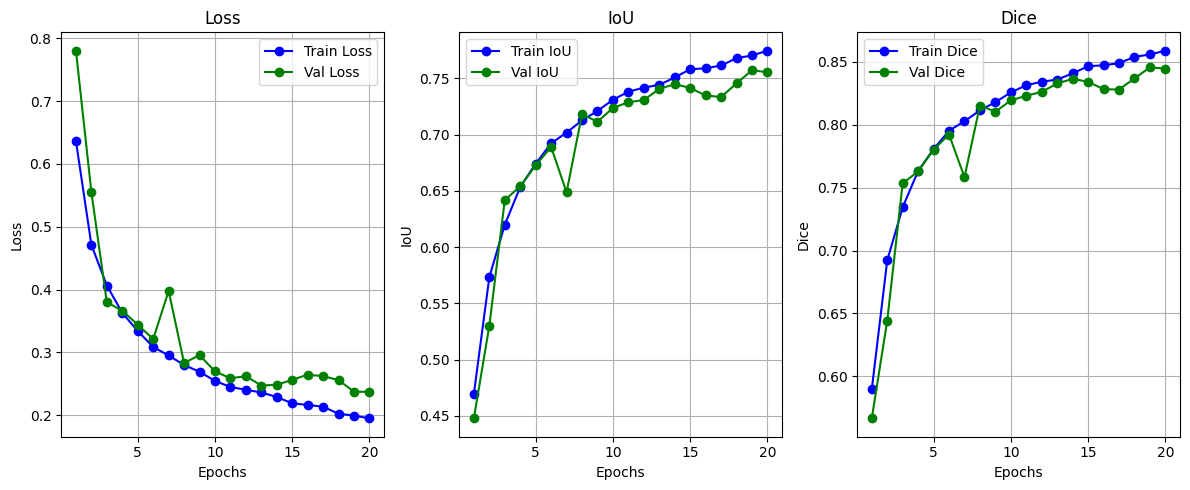

In [46]:
plt.figure(figsize=(12, 5))

    # Courbe de Loss (Train)
plt.subplot(1, 3, 1)
plt.plot(range(1, epochs+1), train_loss, label='Train Loss', color='blue', marker='o')
plt.plot(range(1, epochs+1), test_loss, label='Val Loss', color='green', marker='o')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)
plt.legend()

    # Courbe d'Iou
plt.subplot(1, 3, 2)
plt.plot(range(1, epochs+1), train_iou, label='Train IoU', color='blue', marker='o')
plt.plot(range(1, epochs+1), test_iou, label='Val IoU', color='green', marker='o')
plt.title('IoU')
plt.xlabel('Epochs')
plt.ylabel('IoU')
plt.grid(True)
plt.legend()
    # Courbe de Dice
plt.subplot(1, 3, 3)
plt.plot(range(1, epochs+1), train_dice, label='Train Dice', color='blue', marker='o')
plt.plot(range(1, epochs+1), test_dice, label='Val Dice', color='green', marker='o')
plt.title('Dice')
plt.xlabel('Epochs')
plt.ylabel('Dice')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On observe que le modèle semble continuer à s'améliorer encore après 20 époques mais le gain devient de plus en plus faible et on observe qu'à certaines époques, la loss et les métriques évolue moins bien pour le jeu de test que le jeu d'entrainement . Notamment entre les époques 14 et 18, ce qui nous fait risquer un overfitting si on continue trop longtemps.
Enfin, on affiche un échantillon d'images avec leur masques et la prédiction.

In [47]:
def visualize_batch_segmentation(model, dataset, indices, device):

    model.eval()
    cmap_multi = "jet" 

    plt.figure(figsize=(15, 10))

    for i, idx in enumerate(indices):
        img, mask,_,_ = dataset[idx]
        
        # Le masque est déjà (H, W) de type long, comme corrigé précédemment
        mask_np = mask.cpu().numpy()

        # 1. Préparation de l'image pour le modèle
        img_tensor = img.unsqueeze(0).to(device)

        # 2. Prédiction et Post-traitement MULTI-CLASSE
        with torch.no_grad():
            pred_logits = model(img_tensor)
            
            # Pour la segmentation multi-classe (C=3), on utilise argmax sur la dimension C
            # pred_logits est [B, C, H, W] -> argmax sur dim 1 donne [B, H, W]
            pred_labels = torch.argmax(pred_logits, dim=1)
            
            # Conversion en numpy (H, W)
            pred_np = pred_labels.squeeze().cpu().numpy()

        # 3. Dénormalisation de l'Image (inchangé, mais essentiel)
        # img est de format [C, H, W]. Le permute le met en [H, W, C] pour matplotlib.
        img_np = img.permute(1, 2, 0).cpu().numpy() 
        # Si vous avez utilisé (0.5, 0.5, 0.5) pour la normalisation:
        img_np = img_np * 0.5 + 0.5 
        img_np = np.clip(img_np, 0, 1)

        col = i  # colonne dédiée à cet exemple

        # Affichage (chaque exemple a 3 subplots en colonne)

        # Image originale
        plt.subplot(3, len(indices), col + 1)
        plt.imshow(img_np)
        plt.title(f"Image {idx}")
        plt.axis("off")

        # Masque réel (Ground Truth)
        plt.subplot(3, len(indices), len(indices) + col + 1)
        # Affiche le masque réel. Il est important d'utiliser le même 'cmap' pour GT et Prédiction.
        plt.imshow(mask_np, cmap=cmap_multi, vmin=0, vmax=2) 
        plt.title("GT (Classes 0, 1, 2)")
        plt.axis("off")

        # Masque prédit
        plt.subplot(3, len(indices), 2*len(indices) + col + 1)
        # Affiche la prédiction.
        plt.imshow(pred_np, cmap=cmap_multi, vmin=0, vmax=2) 
        plt.title("Prédiction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

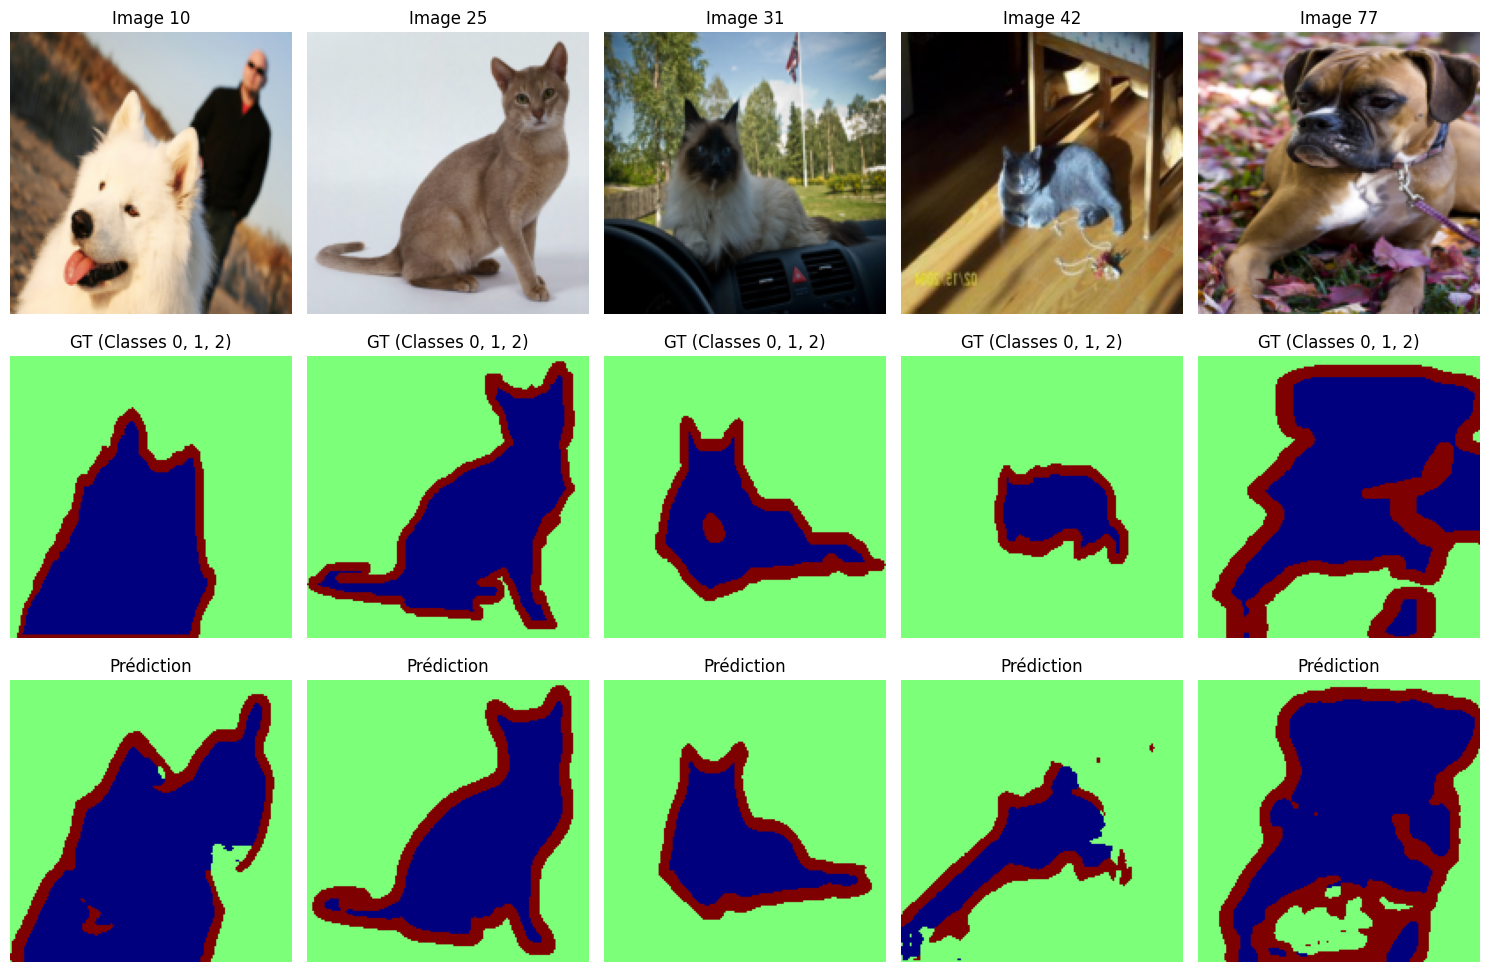

In [48]:
indices = [10, 25, 31, 42, 77]  # par exemple

visualize_batch_segmentation(model_seg, test_dataset, indices, device)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
En regardant les différentes prédictions, on observe que notre modèle est ultra performant sur les images avec un fond/background peu détaillé/uni (3 premières images, même si sur la première notre modèle prend aussi le maître avec). On remarque même que sur la deuxième image qui est une image très net de chat sur fond blanc, notre prédiction semble même plus véridique que la vraie valeur fournie dans le dataset. Pour les images 4 et 5 où respectivement le chat est petit et peut visible à cause de l'ombre et un chien sur un fond très détaillé, notre modèle a plus de mal à retrouver l'animal dans l'image.

<div id="50"></div>
<div style="background-color: #FAE5D3; border-left: 15px solid #CA6F1E; margin-top: 30px; padding: 15px; border-radius: 4px; font-size: 32px; font-family: 'Montserrat', sans-serif; color: #333;">
    <p style="color: #A04000; margin-top: 5px; margin-bottom: 0; font-weight: 700;">
    5. Analyse comparative
</h2>

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- pour mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On charge les poids pour ne pas avoir à tout re calculer à chaque fois.

In [53]:
#chargement du modèle
CHECKPOINT_PATH = 'segmentation.pth'
model_seg = UNet(in_channels=3, out_channels=3).to(device)

model_seg.load_state_dict(torch.load(CHECKPOINT_PATH,weights_only=True)['model_state_dict'])
print("Poids du modèle chargés avec succès.")

Poids du modèle chargés avec succès.


<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On définit des fonctions nous permettant de calculer l'IoU et le dice score pour chaque image et de stocker cette information dans un dataset avec le type d'animal et sa race;

In [54]:
def comp_seg_individuals(model, dataloader, device, breed_mapping=breed_mapping, species_mapping=species_mapping):
    """
    Calcule l'IoU et le Dice Score pour chaque image du dataloader
    et retourne un DataFrame contenant ces métriques ainsi que la race et l'espèce associée
    """
        
    results = [] # Liste pour stocker les résultats de chaque image

    model.eval()
    with torch.no_grad():
        for inputs, masks, specie_tensor, race_tensor in dataloader:
            
            inputs, masks = inputs.to(device), masks.to(device)
            outputs = model(inputs)
            
            # Calcul des métriques par image
            iou_per_image = IoU(outputs, masks, 3).cpu().numpy()
            dice_per_image = dice_score(outputs, masks, 3).cpu().numpy()
            
            race_ids = race_tensor.cpu().numpy().flatten()
            specie_ids = specie_tensor.cpu().numpy().flatten()
            
            batch_size = inputs.size(0)

            
            for i in range(batch_size):
                
                
                race_id = int(race_ids[i])
                
                if 0 < race_id <= len(breed_mapping):
                    breed_name =breed_mapping.loc[breed_mapping["id"] == race_id, "name"].item()
                else:
                    breed_name = f"Unknown_Race_{race_id}"

                specie_id = int(specie_ids[i])
                if 0 <= specie_id < len(species_mapping):
                    specie_name = species_mapping.loc[species_mapping["id"] == specie_id, "name"].item()
                else:
                    specie_name = f"Unknown_Specie_{specie_id}"


                results.append({
                    "breed_name": breed_name,
                    "specie_name": specie_name,
                    "IoU": iou_per_image[i],
                    "dice_score": dice_per_image[i]
                })

    df_individuals = pd.DataFrame(results)
    
    return df_individuals

In [55]:
def plot_metrique(df_individuals, metrique="IoU", abscisse="breed_name", y_min=None):
    """
    Trace une boîte à moustaches (boxplot) des métriques individuelles, 
    avec l'effectif de chaque catégorie affiché sur l'axe des abscisses.
    """
    
    if abscisse not in df_individuals.columns or metrique not in df_individuals.columns:
        print(f"Erreur: Le DataFrame ne contient pas les colonnes '{abscisse}' ou '{metrique}'.")
        return

    effectifs = df_individuals[abscisse].value_counts()
    
    order = effectifs.index.tolist()
    
    nouvelles_etiquettes = [f"{name} ({effectifs.loc[name]})" for name in order]


    plt.figure(figsize=(14, 7))
    
    sns.boxplot(
        x=abscisse, 
        y=metrique, 
        data=df_individuals, 
        order=order,
        palette="viridis", 
        showmeans=True,
        meanprops={"marker":"o", "markerfacecolor":"white", "markeredgecolor":"black", "markersize":"8"}
    )
    
    ax = plt.gca()
    ax.set_xticklabels(nouvelles_etiquettes)

    if y_min is not None:
        plt.ylim(y_min, 1.0) 
        
    plt.title(f'{metrique} en fonction de {abscisse}', fontsize=16)
    plt.xlabel(f'{abscisse} et effectif', fontsize=12)
    plt.ylabel(metrique, fontsize=12)

    plt.xticks(rotation=45, ha='right')

    mean_global = df_individuals[metrique].mean()
    plt.axhline(mean_global, color='r', linestyle='--', linewidth=1, label=f'Moyenne Globale ({mean_global:.3f})')
    plt.legend()
    
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [56]:
df_metriques=comp_seg_individuals(model_seg, test_loader, device, breed_mapping=breed_mapping, species_mapping=species_mapping)

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche les résultats obtenus pour les races.

/tmp/ipykernel_5350/750171259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5350/750171259.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nouvelles_etiquettes)


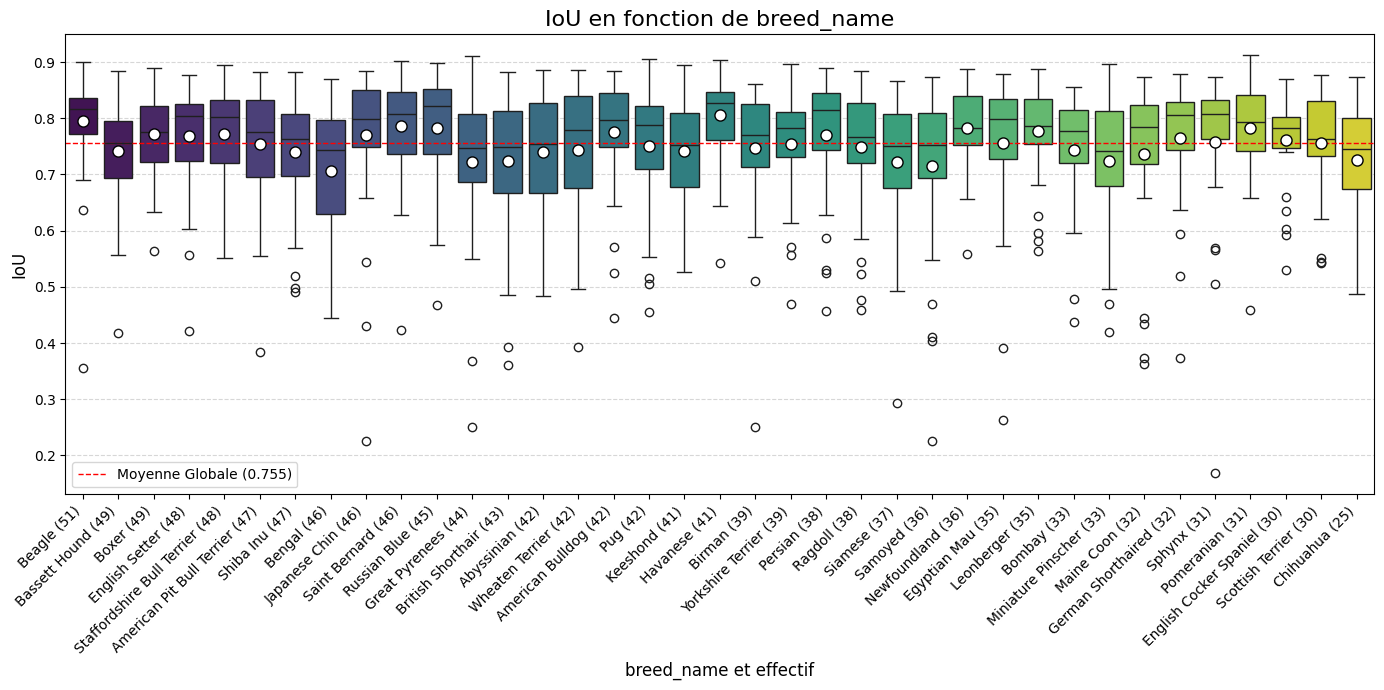

In [57]:
plot_metrique(df_metriques)

/tmp/ipykernel_5350/750171259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5350/750171259.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nouvelles_etiquettes)


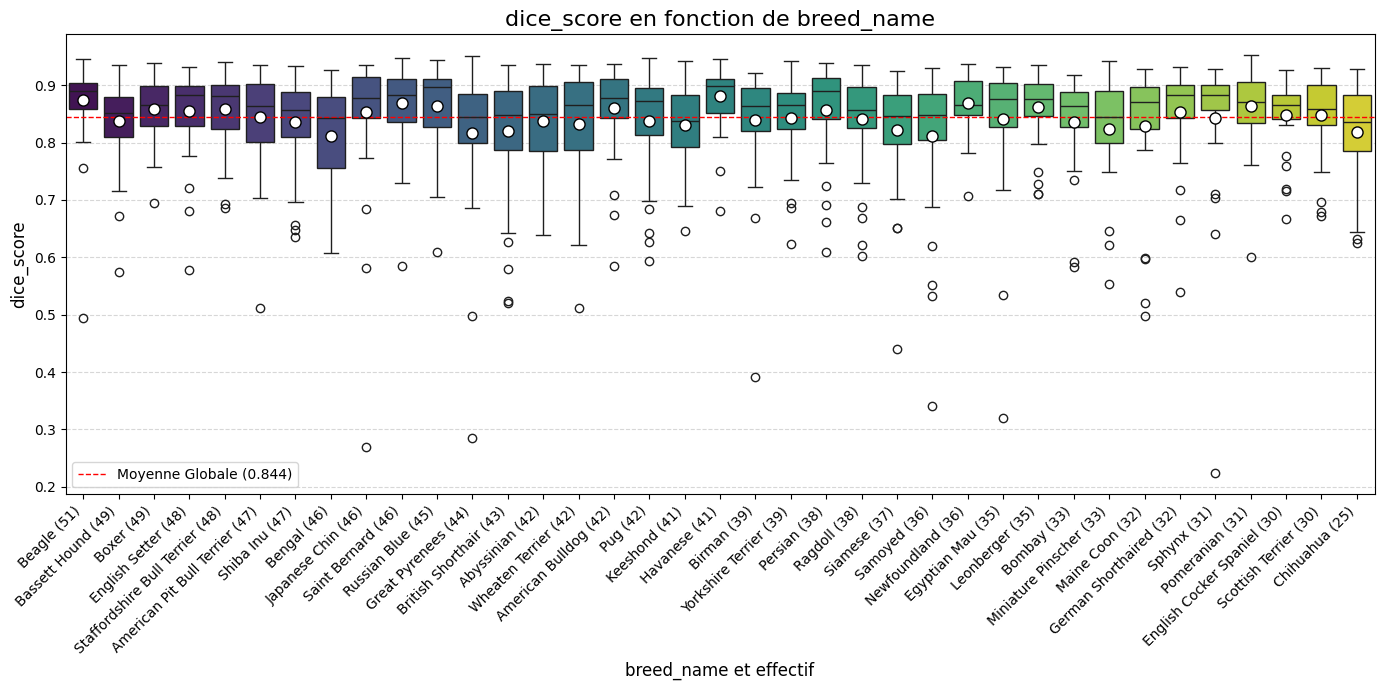

In [58]:
plot_metrique(df_metriques, metrique="dice_score", abscisse="breed_name")

<div style="background-color: #ecf5fb; border-left: 5px solid teal; padding: 15px; border-radius: 4px; font-size: 16px; font-family: 'Montserrat', sans-serif; color: #333;">
    <strong style="color: teal;"></strong> <!-- si tu veux mettre un titre au commentaire -->
    <p style="margin-top: 5px; margin-bottom: 0;">
On affiche nos résultats pour le type d'animal.

/tmp/ipykernel_5350/750171259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5350/750171259.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nouvelles_etiquettes)


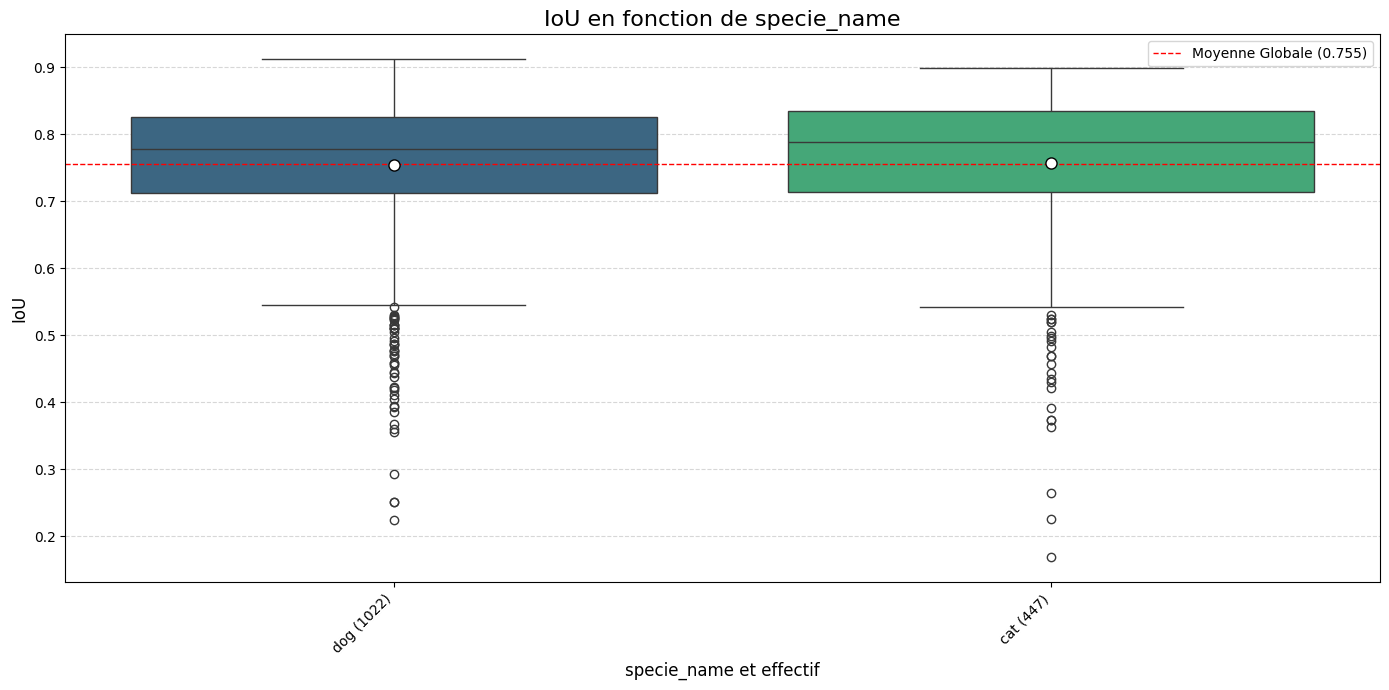

In [59]:
plot_metrique(df_metriques, abscisse="specie_name")

/tmp/ipykernel_5350/750171259.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_5350/750171259.py:31: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(nouvelles_etiquettes)


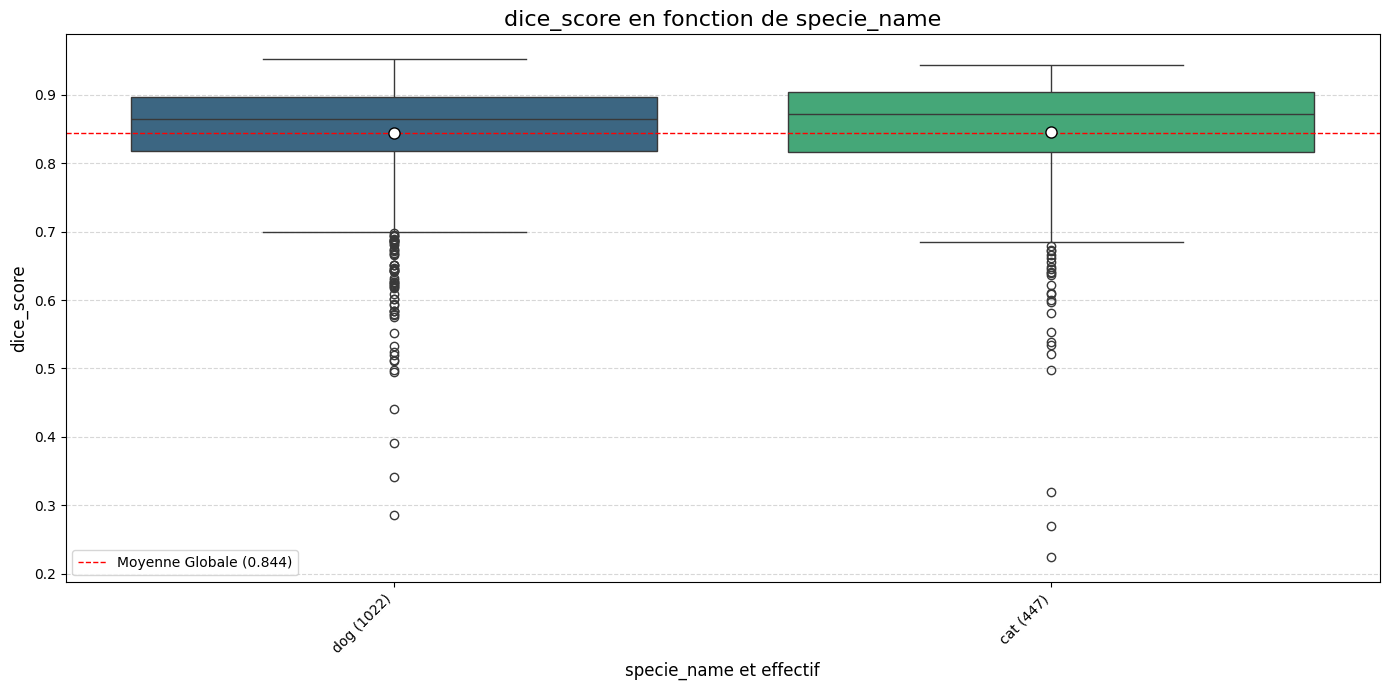

In [60]:
plot_metrique(df_metriques, metrique="dice_score", abscisse="specie_name")